<a href="https://colab.research.google.com/github/MMujtabaX/wordembedding/blob/main/Word_Embeddings_v_TFIDF_DS16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Difference Between Word Embedding and TF-IDF

**Word Embedding**:
- **Definition**: Word embeddings, such as Word2Vec, GloVe, or FastText, are dense vector representations of words that capture their semantic meaning. Each word is mapped to a fixed-size vector in a continuous vector space.
- **Key Features**:
  - Embeddings encode semantic relationships. For example, the vector difference between "king" and "queen" might be similar to the difference between "man" and "woman."
  - They are learned from large text corpora using models like Word2Vec (CBOW or Skip-Gram) or GloVe.
  - They are context-independent (traditional word embeddings). However, newer models like BERT provide context-dependent embeddings.
- **Example**: The vector for "cat" will be close to the vector for "dog" because they share similar contexts in the training data.

**TF-IDF (Term Frequency-Inverse Document Frequency)**:
- **Definition**: TF-IDF is a statistical measure that evaluates the importance of a word in a document relative to a collection of documents. It represents words as sparse vectors.
- **Key Features**:
  - Focuses on the frequency of words and their uniqueness across documents.
  - TF (term frequency) measures how often a word appears in a document.
  - IDF (inverse document frequency) measures how unique or rare a word is across all documents.
  - Words with high TF-IDF values are considered more important in the document.
- **Example**: In a corpus about "dogs," the word "dog" might have a high TF-IDF score in specific documents where it is particularly relevant.

---

| Aspect                  | Word Embedding                                  | TF-IDF                                      |
|-------------------------|------------------------------------------------|--------------------------------------------|
| **Representation**      | Dense, fixed-size vectors.                     | Sparse vectors (dimensionality = vocabulary size). |
| **Semantic Meaning**    | Captures semantic relationships between words. | Does not capture semantic meaning.         |
| **Context**             | Can encode some context (modern embeddings).   | Does not consider word order or context.   |
| **Use Case**            | Useful for semantic tasks (e.g., similarity, clustering). | Good for keyword extraction and document comparison. |
| **Learning Method**     | Trained on large text corpora using neural networks. | Calculated using term frequencies and corpus statistics. |
| **Dimensionality**      | Lower dimensionality, usually predefined (e.g., 100, 300). | Very high dimensionality, equal to the size of the vocabulary. |

---

**Use Case Scenarios**:
- **Word Embeddings**: Ideal for tasks requiring semantic understanding, like word similarity, analogies, and advanced NLP models (e.g., LSTMs or transformers).
- **TF-IDF**: Suitable for keyword extraction, information retrieval, and tasks where frequency-based importance is more relevant.


**CBOW (Continuous Bag of Words):**

- **Objective**: Predict a target word (center word) based on its surrounding context words (neighboring words).
- **Mechanism**:
  1. Given a context window (e.g., two words on each side), CBOW takes the context words as input.
  2. It averages (or sums) the vectors of the context words to create a single vector.
  3. This vector is passed through a neural network to predict the probability distribution of the target word.
  4. The word with the highest probability is chosen as the predicted word.
- **Key Feature**: CBOW is computationally efficient because it uses the aggregated context vector for prediction.
- **Example**: For the sentence "I love natural language processing," if "natural" is the target word and the window size is 2, CBOW uses ["I", "love", "language", "processing"] as input to predict "natural."

---

**Skip-Gram:**

- **Objective**: Predict the context words based on a given target word.
- **Mechanism**:
  1. Skip-gram takes one word (the center word) as input.
  2. It uses this word's vector to predict the probability distribution of the context words.
  3. Each context word is predicted individually, resulting in multiple predictions for one input word.
  4. Words with the highest probabilities are chosen as the predicted context words.
- **Key Feature**: Skip-gram performs well on smaller datasets and captures more detailed semantic relationships.
- **Example**: For the same sentence "I love natural language processing," if "natural" is the center word and the window size is 2, Skip-gram predicts ["I", "love", "language", "processing"] based on "natural."

---

**Key Differences Between CBOW and Skip-Gram**:

| Aspect            | CBOW                                 | Skip-Gram                          |
|-------------------|--------------------------------------|------------------------------------|
| **Prediction**    | Predicts the target word from context | Predicts context words from the target word |
| **Efficiency**    | Computationally efficient            | More computationally intensive      |
| **Dataset Size**  | Suitable for larger datasets         | Works well on smaller datasets      |
| **Detail**        | Captures overall semantic meaning    | Captures fine-grained relationships |
| **Training Speed**| Faster                              | Slower                              |

Both algorithms are part of the Word2Vec model and are widely used in NLP tasks for learning word embeddings.

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 48.8 MB/s eta 0:00:00


Word embeddings are dense vector representations of words that capture semantic meaning.

### Bag of Words Example
   ai  am  amazing  and  are  by  challenging  embeddings  fun  involves  ...  \
0   0   0        0    0    0   0            0           0    0         0  ...   
1   0   1        0    0    0   0            0           0    0         0  ...   
2   1   0        0    0    0   0            0           0    0         0  ...   
3   1   0        0    0    0   1            0           0    0         0  ...   
4   0   0        0    0    0   0            0           0    0         0  ...   
5   0   0        1    0    1   0            0           1    0         0  ...   
6   0   0        0    1    0   0            1           0    1         0  ...   
7   0   0        0    0    0   0            0           0    0         1  ...   

   machine  natural  processing  study  understanding  used  usese  we  word  \
0        0        1           1      0              0     0      0   0     

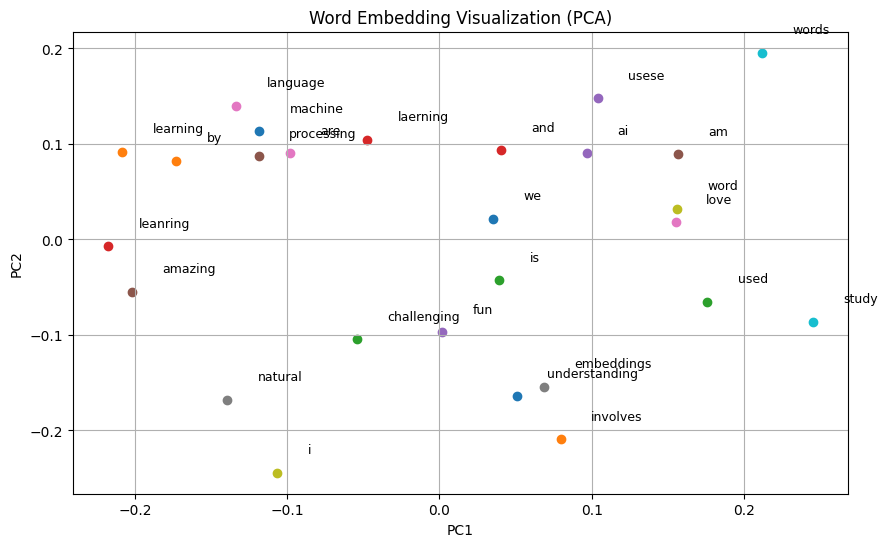


### Cosine Similarity
Cosine similarity between 'natural' and 'language': -0.24

### Word Analogies
Analogy: 'language' is to 'processing' as 'machine' is to: usese


In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Section 1: Introduction
print("Word embeddings are dense vector representations of words that capture semantic meaning.")

# Sample corpus
corpus = [
    "I love natural language processing",
    "I am learning machine learning",
    "Ai usese machine laerning ",
    "Machine leanring is used by AI",
    "we study machine leanring",
    "Word embeddings are amazing",
    "Machine learning is fun and challenging",
    "Natural language processing involves understanding words"
]

# Section 2: Bag of Words
print("\n### Bag of Words Example")
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())
print(bow_df)

# Section 3: TF-IDF
print("\n### TF-IDF Example")
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(tfidf_df)

# Section 4: Word2Vec
print("\n### Word2Vec Example")
# Preprocessing the corpus for Word2Vec
processed_corpus = [sentence.lower().split() for sentence in corpus]

# Training Word2Vec model
w2v_model = Word2Vec(sentences=processed_corpus, vector_size=5, window=2, min_count=1, workers=0)

# Displaying vector for a word
word = "natural"
print(f"Vector for '{word}':\n", w2v_model.wv[word])

# Visualizing Word Embeddings
print("\n### Visualizing Word Embeddings")
words = list(w2v_model.wv.index_to_key)
word_vectors = np.array([w2v_model.wv[w] for w in words])

# Dimensionality reduction using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

# Plotting
plt.figure(figsize=(10, 6))
for word, (x, y) in zip(words, reduced_vectors):
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=9)
plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

# Section 5: Cosine Similarity and Applications
print("\n### Cosine Similarity")
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

word1, word2 = "natural", "language"
similarity = cosine_similarity(w2v_model.wv[word1], w2v_model.wv[word2])
print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.2f}")

# Section 6: Analogies
print("\n### Word Analogies")
result = w2v_model.wv.most_similar(positive=["language", "processing"], negative=["machine"], topn=1)
print("Analogy: 'language' is to 'processing' as 'machine' is to:", result[0][0])


# PreTrained

In [3]:
import kagglehub
#path = kagglehub.dataset_download("watts2/glove6b50dtxt")

In [4]:
file_name

NameError: name 'file_name' is not defined

In [ ]:
# # importing required modules
# from zipfile import ZipFile

# # specifying the zip file name
# #file_name = "/content/glove.6B.50d.txt.zip"
# file_name = kagglehub.dataset_download("watts2/glove6b50dtxt")
# # opening the zip file in READ mode
# with ZipFile("filepath", 'r') as zipdata:
# 	# printing all the contents of the zip file
# 	zipdata.printdir()

# 	# extracting all the files
# 	print('Extracting all the files now...')
# 	zipdata.extractall()
# 	print('Done!')


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec, KeyedVectors
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Section 1: Introduction
print("Word embeddings are dense vector representations of words that capture semantic meaning.")

# Section 2: Load Pre-trained Word Embedding
print("\n### Loading Pre-trained Word Embedding")
# Using GloVe pre-trained embeddings (for demonstration, assume 'glove.6B.50d.txt' is available)
def load_glove_model(file_path):
    embeddings_index = {}
    with open(file_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_file_path = "/root/.cache/kagglehub/datasets/watts2/glove6b50dtxt/versions/1/glove.6B.50d.txt"
glove_embeddings = load_glove_model(glove_file_path)
print(f"Loaded {len(glove_embeddings)} word vectors.")

# Section 3: Use Case - Similarity
print("\n### Cosine Similarity with Pre-trained Embeddings")
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

word1, word2 = "king", "queen"
if word1 in glove_embeddings and word2 in glove_embeddings:
    similarity = cosine_similarity(glove_embeddings[word1], glove_embeddings[word2])
    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.2f}")
else:
    print(f"Words '{word1}' or '{word2}' not in vocabulary.")

# Section 4: Use Case - Analogies
print("\n### Word Analogies with Pre-trained Embeddings")
def find_analogy(word_a, word_b, word_c, embeddings):
    if word_a in embeddings and word_b in embeddings and word_c in embeddings:
        analogy_vector = embeddings[word_b] - embeddings[word_a] + embeddings[word_c]
        similarity = {word: cosine_similarity(analogy_vector, vec) for word, vec in embeddings.items()}
        return sorted(similarity.items(), key=lambda x: x[1], reverse=True)[1:6]  # Exclude the input word
    else:
        return None

result = find_analogy("water", "drink", "tea", glove_embeddings)
if result:
    print("'computer' is to 'keyboard' as 'car' is to:")
    for word, score in result:
        print(f"  {word}: {score:.2f}")
else:
    print("One or more words not found in the vocabulary.")

# Section 5: Visualization
print("\n### Visualizing Pre-trained Embeddings")
words_to_visualize = ["king", "queen", "man", "woman", "child", "royalty"]
embeddings_to_visualize = [glove_embeddings[word] for word in words_to_visualize if word in glove_embeddings]

# Dimensionality reduction using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(embeddings_to_visualize)

# Plotting
plt.figure(figsize=(10, 6))
for word, (x, y) in zip(words_to_visualize, reduced_vectors):
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=9)
plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()


# Training Word Embedding

In [ ]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pickle

# Section 1: Create Custom Corpus
print("### Creating a Custom Corpus")
custom_corpus = [
    "I love natural language processing",  # Example sentence about NLP
    "Word embeddings are very useful",  # Highlighting embeddings utility
    "Machine learning is fun",  # General machine learning statement
    "Natural language understanding is a key task in NLP"  # Emphasizing NLP tasks
]

# Preprocessing the corpus by splitting sentences into lowercase words
processed_corpus = [sentence.lower().split() for sentence in custom_corpus]
print("Processed Corpus:", processed_corpus)

# Section 2: Train Word2Vec Model
print("\n### Training Word2Vec Model")
# Training a Word2Vec model with Skip-gram architecture
# Skip-gram predicts context words given a target word, capturing finer semantic details
w2v_model = Word2Vec(
    sentences=processed_corpus,  # Input corpus
    vector_size=50,  # Dimensionality of word vectors
    window=2,  # Context window size
    min_count=1,  # Minimum word frequency for inclusion
    sg=1,  # Use Skip-gram (sg=1). Set to 0 for CBOW (Continuous Bag of Words)
    workers=1  # Number of worker threads (set to 1 for simplicity)
)

# Save the model for later use
model_path = "custom_word2vec.model"
w2v_model.save(model_path)  # Save the trained Word2Vec model
print(f"Model saved to {model_path}")

# Save the vectors as a dictionary
vectors_path = "custom_word_vectors.pkl"
# Extract word vectors and store them in a dictionary
word_vectors = {word: w2v_model.wv[word] for word in w2v_model.wv.index_to_key}
with open(vectors_path, "wb") as f:
    pickle.dump(word_vectors, f)  # Save the word vectors to a file
print(f"Word vectors saved to {vectors_path}")

# Section 3: Load and Use the Model
print("\n### Loading Saved Model")
# Load the saved Word2Vec model
loaded_model = Word2Vec.load(model_path)
print("Model loaded successfully.")

# Load saved vectors from the file
with open(vectors_path, "rb") as f:
    loaded_vectors = pickle.load(f)
print("Word vectors loaded successfully.")

# Section 4: Explore the Embeddings
print("\n### Exploring Word Embeddings")
word = "natural"  # Specify a word to explore
if word in loaded_model.wv:
    # Display the vector representation of the word
    print(f"Vector for '{word}':\n", loaded_model.wv[word])

# Section 5: Visualize Word Embeddings
print("\n### Visualizing Word Embeddings")
# Select a subset of words to visualize (up to 10 words)
words_to_visualize = list(loaded_vectors.keys())[:10]
# Retrieve the corresponding vectors for the selected words
embeddings_to_visualize = np.array([loaded_vectors[word] for word in words_to_visualize])

# Dimensionality reduction using PCA to 2D for visualization
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(embeddings_to_visualize)

# Plotting the reduced word vectors
plt.figure(figsize=(10, 6))
for word, (x, y) in zip(words_to_visualize, reduced_vectors):
    plt.scatter(x, y)  # Plot each word vector
    plt.text(x + 0.02, y + 0.02, word, fontsize=9)  # Annotate the plot with the word
plt.title("Custom Word Embedding Visualization (PCA)")
plt.xlabel("PC1")  # Label for the first principal component
plt.ylabel("PC2")  # Label for the second principal component
plt.grid()  # Display a grid for better readability
plt.show()

# Note:
# Skip-gram is used in this example (sg=1). It focuses on predicting context words given a target word.
# CBOW (sg=0) predicts the target word from surrounding context words and is computationally more efficient.


# Word Embedding Applications

In [ ]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load a pre-trained Word2Vec model or use an existing one
model_path = "custom_word2vec.model"
w2v_model = Word2Vec.load(model_path)  # Load the pre-trained model from disk

# Section 1: Semantic Similarity
print("\n### Semantic Similarity")
def semantic_similarity(word1, word2):
    # Check if both words are in the vocabulary
    if word1 in w2v_model.wv and word2 in w2v_model.wv:
        # Compute cosine similarity between word vectors
        similarity = cosine_similarity([w2v_model.wv[word1]], [w2v_model.wv[word2]])[0][0]
        return similarity
    else:
        return None

word1, word2 = "natural", "language"
similarity = semantic_similarity(word1, word2)
if similarity is not None:
    print(f"Semantic similarity between '{word1}' and '{word2}': {similarity:.2f}")
else:
    print(f"One or both words ('{word1}', '{word2}') are not in the vocabulary.")

# Section 2: Word Analogies
print("\n### Word Analogies")
def word_analogy(word_a, word_b, word_c):
    # Check if all three words are in the vocabulary
    if word_a in w2v_model.wv and word_b in w2v_model.wv and word_c in w2v_model.wv:
        # Perform the analogy calculation: word_b - word_a + word_c
        result = w2v_model.wv.most_similar(positive=[word_b, word_c], negative=[word_a], topn=1)
        return result[0]
    else:
        return None

analogy_result = word_analogy("man", "king", "woman")
if analogy_result:
    print(f"'man' is to 'king' as 'woman' is to '{analogy_result[0]}' (similarity: {analogy_result[1]:.2f})")
else:
    print("One or more words are not in the vocabulary.")

# Section 3: Clustering Words
print("\n### Clustering Words")
# def cluster_words(words):
#     # Retrieve vectors for the words in the vocabulary
#     vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
#     # Reduce dimensions to 2D for visualization using PCA
#     reduced_vectors = PCA(n_components=2).fit_transform(vectors)
#     plt.figure(figsize=(10, 6))
#     # Plot the words in the 2D space
#     for word, (x, y) in zip(words, reduced_vectors):
#         plt.scatter(x, y)
#         plt.text(x + 0.02, y + 0.02, word, fontsize=9)
#     plt.title("Word Clustering Visualization")
#     plt.grid()
#     plt.show()
def cluster_words(words):
    # Retrieve vectors for the words in the vocabulary
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]

    # Check if any vectors were retrieved
    if len(vectors) == 0:
        print("None of the words are in the vocabulary.")
        return

    # Reduce dimensions to 2D for visualization using PCA
    reduced_vectors = PCA(n_components=2).fit_transform(vectors)

    # Plot the words in the 2D space
    plt.figure(figsize=(10, 6))
    for word, (x, y) in zip(words, reduced_vectors):
        plt.scatter(x, y)
        plt.text(x + 0.02, y + 0.02, word, fontsize=9)
    plt.title("Word Clustering Visualization")
    plt.grid()
    plt.show()
words_to_cluster = ["king", "queen", "man", "woman", "child", "prince", "princess"]
cluster_words(words_to_cluster)

# Section 4: Document Similarity
print("\n### Document Similarity")
def document_vector(document):
    # Tokenize the document into words and filter valid words in the vocabulary
    words = document.lower().split()
    valid_words = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    # Compute the mean vector of all valid word vectors
    return np.mean(valid_words, axis=0) if valid_words else None

doc1 = "I love natural language processing"
doc2 = "Natural language understanding is important"
vec1, vec2 = document_vector(doc1), document_vector(doc2)
if vec1 is not None and vec2 is not None:
    # Compute cosine similarity between document vectors
    similarity = cosine_similarity([vec1], [vec2])[0][0]
    print(f"Similarity between documents: {similarity:.2f}")
else:
    print("One or both documents have no valid words in the vocabulary.")

# Section 5: Sentiment Analysis (Basic Example)
print("\n### Sentiment Analysis")
def sentiment_score(word):
    # Define basic positive and negative word lists
    positive_words = ["good", "happy", "joy", "excellent"]
    negative_words = ["bad", "sad", "anger", "poor"]
    # Assign scores based on presence in the lists
    if word in positive_words:
        return 1
    elif word in negative_words:
        return -1
    else:
        return 0

def analyze_sentiment(document):
    # Tokenize the document into words
    words = document.lower().split()
    # Compute sentiment scores for each word and return the average score
    scores = [sentiment_score(word) for word in words]
    return np.mean(scores) if scores else 0

document = "I am very happy with this excellent service"
sentiment = analyze_sentiment(document)
if sentiment > 0:
    print("Positive sentiment")
elif sentiment < 0:
    print("Negative sentiment")
else:
    print("Neutral sentiment")
